In [2]:
import pandas as pd

In [6]:
%pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 793.5 kB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import mysql.connector

In [ ]:
import mysql.connector
import pandas as pd

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="YOUR_PASSWORD",
    database="customer_churn_db"
)

query = "SELECT * FROM customer_churn"

df = pd.read_sql(query, connection)

df.head()

In [ ]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="YOUR_PASSWORD",
    database="customer_churn_db"
)

In [9]:
query = "SELECT * FROM customer_churn"

In [10]:
df = pd.read_sql(query, connection)

/var/folders/gf/rn8lrr5d3pvdgnkhfmp5ctv00000gn/T/ipykernel_2835/1848774206.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
%pip install seaborn matplotlib scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 MB 1.8 MB/s eta 0:00:0000:0100:04m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 1.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 2.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 2.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 2.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 3.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

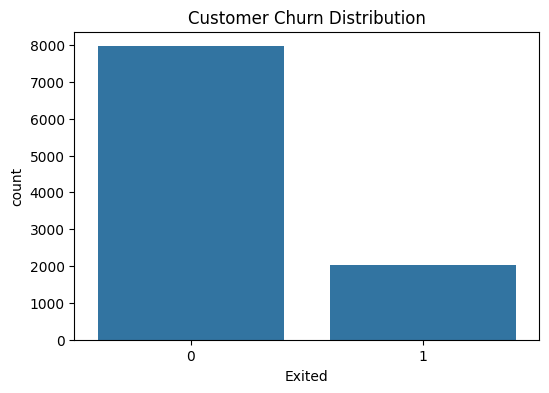

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

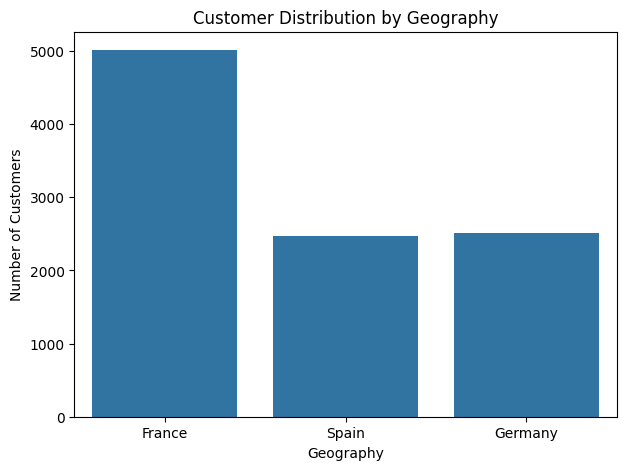

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(x="Geography", data=df)
plt.title("Customer Distribution by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.show()

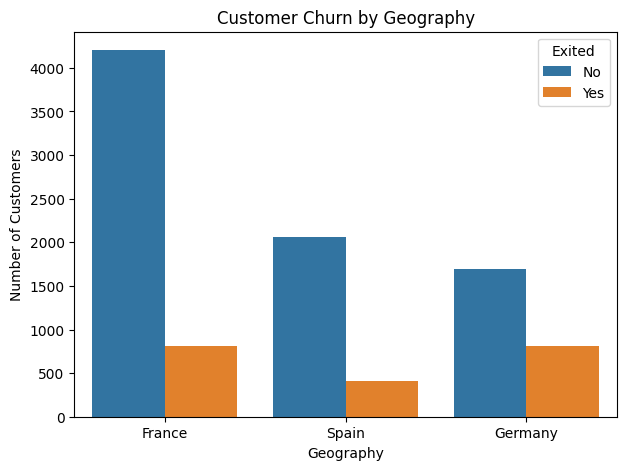

In [22]:
plt.figure(figsize=(7,5))
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.legend(title="Exited", labels=["No", "Yes"])
plt.show()

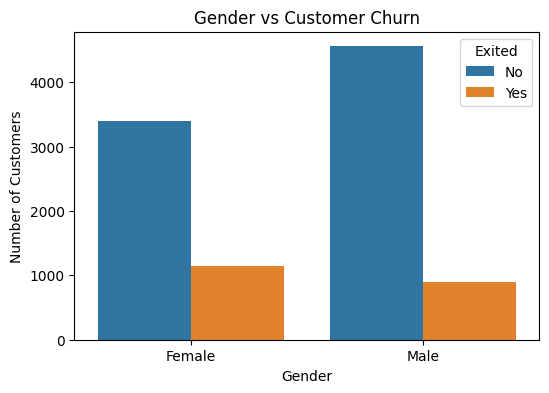

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Exited", labels=["No", "Yes"])
plt.show()

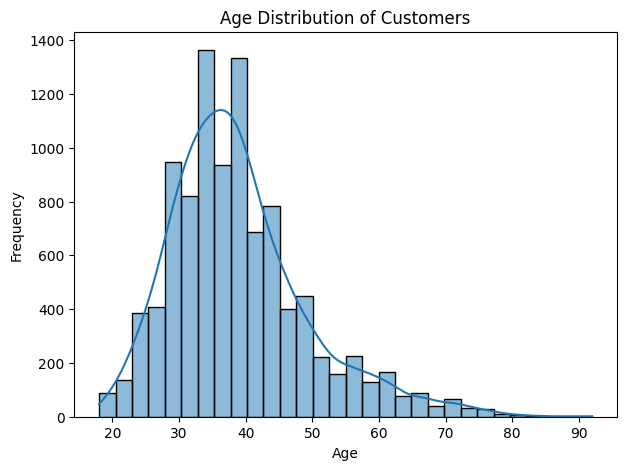

In [24]:
plt.figure(figsize=(7,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

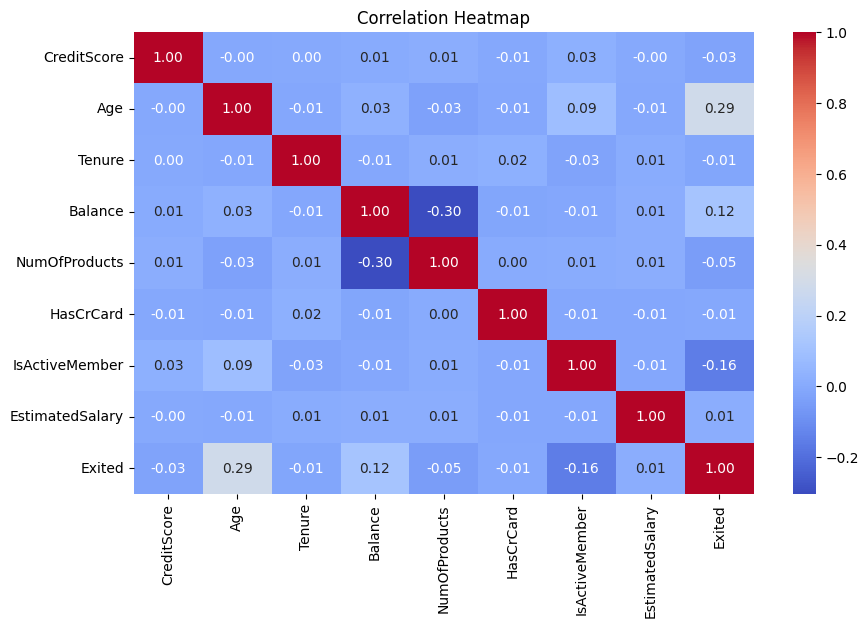

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [29]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [30]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [31]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [32]:
X.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X["Gender"] = le.fit_transform(X["Gender"])

In [34]:
X = pd.get_dummies(X, columns=["Geography"], drop_first=True)

In [39]:
X.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True
5,645,1,44,8,113755.78,2,1,0,149756.71,False,True
6,822,1,50,7,0.00,2,1,1,10062.80,False,False
7,376,0,29,4,115046.74,4,1,0,119346.88,True,False
8,501,1,44,4,142051.07,2,0,1,74940.50,False,False
9,684,1,27,2,134603.88,1,1,1,71725.73,False,False


In [40]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
sc = StandardScaler()

In [48]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [49]:
print(X_train[:5])

[[ 0.35649971  0.91324755 -0.6557859   0.34567966 -1.21847056  0.80843615
   0.64920267  0.97481699  1.36766974 -0.57946723 -0.57638802]
 [-0.20389777  0.91324755  0.29493847 -0.3483691   0.69683765  0.80843615
   0.64920267  0.97481699  1.6612541   1.72572313 -0.57638802]
 [-0.96147213  0.91324755 -1.41636539 -0.69539349  0.61862909 -0.91668767
   0.64920267 -1.02583358 -0.25280688 -0.57946723  1.73494238]
 [-0.94071667 -1.09499335 -1.13114808  1.38675281  0.95321202 -0.91668767
   0.64920267 -1.02583358  0.91539272 -0.57946723 -0.57638802]
 [-1.39733684  0.91324755  1.62595257  1.38675281  1.05744869 -0.91668767
  -1.54035103 -1.02583358 -1.05960019 -0.57946723 -0.57638802]]


In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [54]:
model = Sequential()

model.add(Dense(units=6, activation="relu"))
model.add(Dense(units=6, activation="relu"))

In [55]:
model.add(Dense(units=1, activation="sigmoid"))

In [56]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [57]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - accuracy: 0.6723 - loss: 0.6157 - val_accuracy: 0.7931 - val_loss: 0.5085
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.7925 - loss: 0.4829 - val_accuracy: 0.7987 - val_loss: 0.4642
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - accuracy: 0.7936 - loss: 0.4536 - val_accuracy: 0.7994 - val_loss: 0.4440
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - accuracy: 0.7966 - loss: 0.4349 - val_accuracy: 0.8006 - val_loss: 0.4301
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - accuracy: 0.8009 - loss: 0.4213 - val_accuracy: 0.8050 - val_loss: 0.4184
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - accuracy: 0.8070 - loss: 0.4093 - val_accuracy: 0.8100 - val_loss: 0.4078
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.8125 - loss: 0.3981 - val_accuracy: 0.8144 - val_loss: 0.3987
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.8150 - loss: 0

In [59]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - accuracy: 0.8595 - loss: 0.3447
Test Loss: 0.3446802794933319
Test Accuracy: 0.859499990940094


In [60]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step


In [61]:
y_pred = (y_pred > 0.5)

In [62]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1532   75]
 [ 206  187]]


In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.92      1607
           1       0.71      0.48      0.57       393

    accuracy                           0.86      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [64]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.7145780784133031


In [65]:
model.save("customer_churn.model.keras")

In [66]:
import joblib

joblib.dump(sc, "scaler.pkl")

print("Scaler Saved Successfully!")

Scaler Saved Successfully!
